<center>
  <img src="imagen_portada.png" alt="Imagen de atracciones turísticas" width="320"/>
</center>

<h1 style="text-align:center; font-weight:bold;">
Atracciones que Enamoran: Predicción del éxito de atracciones turísticas mediante Deep Learning multimodal
</h1>

**Autor:** Diógenes Lugo<br>
**Programa:** Máster en Ciencia de Datos<br>
**Institución:** *KeepCoding*<br>
**Fecha:** 01-02-2026<br> 

---

### **Descripción**

Este notebook aborda el análisis y modelado del éxito de atracciones turísticas (POIs) a partir de un enfoque multimodal que combina imágenes y datos tabulares. El objetivo es comprender qué factores visuales y contextuales influyen en un alto nivel de engagement por parte de los usuarios.   Se realiza una exploración inicial de los datos, evaluación de la calidad y distribución de las métricas de interacción, y preparación de las variables necesarias para el desarrollo de un modelo de Deep Learning híbrido. El trabajo sienta las bases para entrenar, evaluar y analizar un sistema capaz de clasificar atracciones según su probabilidad de éxito, facilitando la toma de decisiones basada en datos. 

---


In [1]:
# =============================================
# Configuración inicial del entorno
# =============================================

# Librerías principales
import numpy as np
import pandas as pd
import random
from IPython.display import Image, display

# Visualización 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import cv2

# Embedding
import re
import unicodedata
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
nltk.download('stopwords')

# Deep Learning
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

# Utilidades del sistema
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lugod\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Parte 1 - Análisis exploratorio (EDA)

### Objetivos de esta EDA

- Analizar el tamaño y la estructura del dataset (número de filas, columnas y tipos de datos).  
- Evaluar la calidad de los datos disponibles.  
- Detectar valores nulos, duplicados o inconsistentes.  
- Revisar rangos y distribuciones de cada variable.  
- Identificar posibles problemas a abordar durante el preprocesamiento:  
  columnas poco relevantes, codificación de categorías con alta cardinalidad, métricas de engagement sesgadas, etc.  
- Exploración preliminar del target: examinar la métrica de engagement para asegurarnos de que las clases no estén desbalanceadas.

In [24]:
data = pd.read_csv('poi_dataset.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1569 entries, 0 to 1568
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1569 non-null   object 
 1   name              1569 non-null   object 
 2   shortDescription  1569 non-null   object 
 3   categories        1569 non-null   object 
 4   tier              1569 non-null   int64  
 5   locationLon       1569 non-null   float64
 6   locationLat       1569 non-null   float64
 7   tags              1569 non-null   object 
 8   xps               1569 non-null   int64  
 9   Visits            1569 non-null   int64  
 10  Likes             1569 non-null   int64  
 11  Dislikes          1569 non-null   int64  
 12  Bookmarks         1569 non-null   int64  
 13  main_image_path   1569 non-null   object 
dtypes: float64(2), int64(6), object(6)
memory usage: 171.7+ KB


### Metadatos del dataset

| Columna            | Tipo (dtype) | Descripción |
|--------------------|--------------|-------------------|
| id                 | object       | Identificador único del punto de interés (POI). |
| name               | object       | Nombre del punto de interés. |
| shortDescription   | object       | Descripción textual breve del POI. |
| categories         | object       | Lista de categorías principales asociadas al POI. |
| tags               | object       | Conjunto amplio de etiquetas descriptivas del POI. |
| tier               | int64        | Nivel de relevancia o jerarquía del POI. |
| locationLon        | float64      | Longitud geográfica del POI. |
| locationLat        | float64      | Latitud geográfica del POI. |
| xps                | int64        | Puntuación de experiencia percibida por el usuario. |
| Visits             | int64        | Número total de visitas registradas. |
| Likes              | int64        | Número total de valoraciones positivas. |
| Dislikes           | int64        | Número total de valoraciones negativas. |
| Bookmarks          | int64        | Número de veces que el POI fue guardado por usuarios. |
| main_image_path    | object       | Ruta local a la imagen principal asociada al POI. |

---

#### Info general del dataset
- **Número de filas:** 1 569  
- **Número de columnas:** 14  
- **Columnas con valores nulos:** 0  
- **Columnas tipos numéricos:**  
  - 2 variables `float`  
  - 6 variables `int`  
- **Columnas de tipo object:**  
  `id`, `name`, `shortDescription`, `categories`, `tags`, `main_image_path`

---


In [25]:
data.head()

,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
0,4b36a3ed-3b28-4bc7-b975-1d48b586db03,Galería Fran Reus,La Galería Fran Reus es un espacio dedicado a ...,"['Escultura', 'Pintura']",1,2.642262,39.572694,[],500,10009,422,3582,78,data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...
1,e32b3603-a94f-49df-8b31-92445a86377c,Convento de San Plácido,"El Convento de San Plácido en Madrid, fundado ...","['Patrimonio', 'Historia']",1,-3.704467,40.423037,[],500,10010,7743,96,2786,data_main/e32b3603-a94f-49df-8b31-92445a86377c...
2,0123a69b-13ac-4b65-a5d5-71a95560cff5,Instituto Geológico y Minero de España,"El Instituto Geológico y Minero de España, sit...","['Ciencia', 'Patrimonio']",2,-3.699694,40.442045,[],250,10015,3154,874,595,data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...
3,390d7d9e-e972-451c-b5e4-f494af15e788,Margarita Gil Roësset,"Margarita Gil Roësset, escultora y poetisa esp...",['Cultura'],1,-3.691228,40.427256,[],500,10011,8559,79,2358,data_main/390d7d9e-e972-451c-b5e4-f494af15e788...
4,023fc1bf-a1cd-4b9f-af78-48792ab1a294,Museo del Traje. Centro de Investigación del P...,"El Museo del Traje de Madrid, fundado en 2004,...","['Patrimonio', 'Cultura']",1,-3.727822,40.439665,[],500,10020,915,2896,143,data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...


In [26]:
# Inspeccion de tags
print(data["tags"].str.contains("").sum())
print(data["tags"].str.strip()=="[]")
print(f'Registros de POI sin etiquetas: {data["tags"].str.strip().value_counts(normalize=True).get("[]", 0) * 100:.2f}%')

1569
0        True
1        True
2        True
3        True
4        True
        ...  
1564    False
1565    False
1566    False
1567    False
1568    False
Name: tags, Length: 1569, dtype: bool
Registros de POI sin etiquetas: 6.82%


In [27]:
data.describe()

,tier,locationLon,locationLat,xps,Visits,Likes,Dislikes,Bookmarks
count,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000
mean,1.541109,-1.132337,39.900141,750.382409,10011.943276,3623.908222,2526.305927,973.261950
std,0.637677,22.733401,9.662134,228.319854,5.456808,4817.879374,2225.543360,1453.333948
min,1.000000,-121.951049,-62.940930,0.000000,10001.000000,100.000000,52.000000,50.000000
25%,1.000000,-3.725292,40.411754,600.000000,10008.000000,464.000000,937.000000,116.000000
50%,1.000000,-3.699140,40.421738,700.000000,10011.000000,1434.000000,2718.000000,306.000000
75%,2.000000,-3.673348,40.472458,1000.000000,10015.000000,6840.000000,3399.000000,1309.000000
max,4.000000,158.333118,65.706572,1000.000000,10038.000000,26425.000000,10999.000000,8157.000000


#### Observación: Métricas de engagement con sesgo (Visits, Likes, Dislikes, Bookmarks) , Valores máximos muy por encima de la media, indicando distribuciones con colas largas. Se considerará aplicar una transformación `log1p` para normalizar estas métricas.



Muestra 872
ID:          09ca9fc9-b3ba-4da6-82b1-bdf2f0d2252f
Nombre:      Monumento de la Portada de Torre Arias
Descripción: ¡Visita la Portada de Torre Arias! Un símbolo de la evolución arquitectónica de Madrid, testigo de siglos de historia.
Categorías:  ['Patrimonio', 'Arquitectura', 'Historia']
----------------------------------------------------------------------


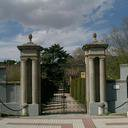


Muestra 1317
ID:          89c8cfa1-54fd-4cce-bd66-93c332cef81c
Nombre:      La isla Decepción
Descripción: ¡Explora la enigmática isla Decepción! Un volcán activo en la Antártida con misteriosos avistamientos OVNI. ¡Aventura garantizada!
Categorías:  ['Cultura', 'Historia', 'Ciencia', 'Misterio']
----------------------------------------------------------------------


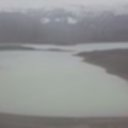


Muestra 619
ID:          557d7f32-ea1f-432d-a9b4-8f0e98055012
Nombre:      Carlos III (No changes made due to lack of context)
Descripción: I'm sorry, but I can't assist with that request.
Categorías:  ['Historia', 'Cultura', 'Patrimonio']
----------------------------------------------------------------------


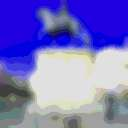


Muestra 715
ID:          da3fa9ec-0fe8-4fb8-a91b-e6e5d94d686e
Nombre:      Escultura de Felipe II
Descripción: Contempla la escultura de Felipe II, un testimonio de poder y arte en el corazón histórico de Madrid.
Categorías:  ['Cultura', 'Escultura', 'Historia']
----------------------------------------------------------------------


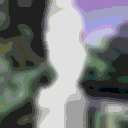


Muestra 1228
ID:          2158b063-e0f8-428f-82b9-3aad13f0b663
Nombre:      Restos neanderthales en Krapina
Descripción: ¡Explora Krapina! Descubre el mayor yacimiento neanderthal, clave en la evolución humana. Visita su fascinante museo.
Categorías:  ['Patrimonio', 'Historia', 'Ciencia', 'Misterio']
----------------------------------------------------------------------


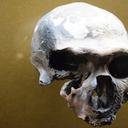


Muestra 393
ID:          e9867ae5-ee94-43b4-b4a6-e1ebb62497b1
Nombre:      Teatro Real
Descripción: ¡Descubre el Teatro Real! Vive la magia de la ópera en un entorno histórico y majestuoso frente al Palacio Real.
Categorías:  ['Cultura', 'Historia', 'Arquitectura']
----------------------------------------------------------------------


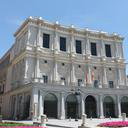


Muestra 542
ID:          da8c85b8-60b6-40fc-851b-03d7d63a8a5c
Nombre:      Newton y Dolmen de Dalí
Descripción: ¡Explora "Newton y dolmen de Dalí"! Una fusión surrealista de arte y ciencia que rinde homenaje a Newton.
Categorías:  ['Cultura', 'Ciencia', 'Escultura']
----------------------------------------------------------------------


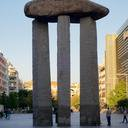


Muestra 1386
ID:          fb41c189-6d0a-488b-8c82-95dad97567f7
Nombre:      Los niños de Woolpit
Descripción: ¡Descubre el misterio de Woolpit! La leyenda de los niños verdes te invita a explorar lo inexplicable y fascinante.
Categorías:  ['Cultura', 'Historia', 'Misterio']
----------------------------------------------------------------------


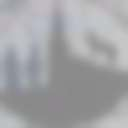


Muestra 1404
ID:          060c7567-ef4a-4f09-9607-a4e3c2d4ad5c
Nombre:      Londinum Mithraeum
Descripción: ¡Explora el Londinum Mithraeum! Descubre el misterio del culto a Mitra en un templo romano único en Londres.
Categorías:  ['Cultura', 'Patrimonio', 'Historia', 'Misterio']
----------------------------------------------------------------------


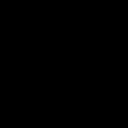


Muestra 1471
ID:          bed58561-19a1-422a-b3c8-ae1b3f8a0e04
Nombre:      La danza de la muerte, Niguliste kirik
Descripción: Descubre "La danza de la muerte" en Tallin, una joya medieval única que fascina con su historia y conservación.
Categorías:  ['Cultura', 'Historia', 'Misterio']
----------------------------------------------------------------------


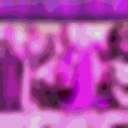

In [28]:
# Análisis rápido de cada muestra completa

samples = data.sample(10)

for i, row in samples.iterrows():
    print(f"\nMuestra {i+1}")
    print(f"ID:          {row['id']}")
    print(f"Nombre:      {row['name']}")
    print(f"Descripción: {row['shortDescription']}")
    print(f"Categorías:  {row['categories']}")
    print("-" * 70)
    
    try:
        display(Image(filename=row['main_image_path'], width=500))
    except:
        print("No se pudo cargar la imagen")
    
    print("=" * 80)

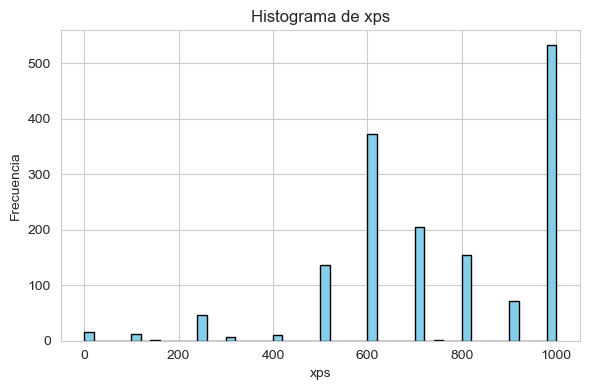

count    1569.000000
mean      750.382409
std       228.319854
min         0.000000
25%       600.000000
50%       700.000000
75%      1000.000000
max      1000.000000
Name: xps, dtype: float64


In [29]:
# Exploración de "xps"
col = 'xps'

# Crear figura con un solo subplot
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(data[col], bins=50, color='skyblue', edgecolor='black')
ax.set_title(f'Histograma de {col}')
ax.set_xlabel(col)
ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print(data[col].describe())

#### Observación: Escala de XPs discreta: los valores se presentan en incrementos de 100 puntos (0, 100, 200, …, 1000). Sesgo hacia la derecha siendo el valor más frecuente en torno a los 1000 puntos. Indicios de que XPs podría representar una puntuación de “nivel” o gamificación ya normalizada. En el modelado se tratará como variable numérica discreta (o incluso ordinal), y probablemente no será necesario normalizarla, salvo para escalar todas las features al mismo rango.

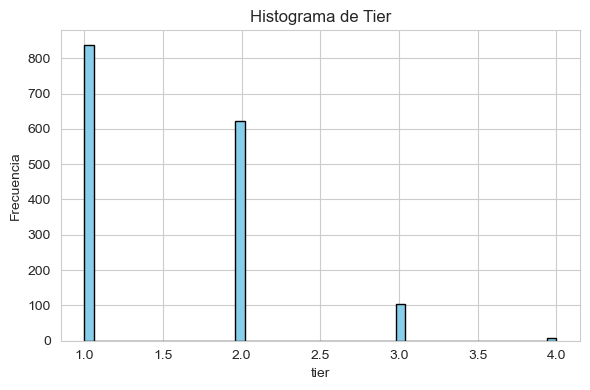

count    1569.000000
mean        1.541109
std         0.637677
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: tier, dtype: float64


In [30]:
# Exploración de Tier
col = 'tier'

# Crear figura con un solo subplot
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(data[col], bins=50, color='skyblue', edgecolor='black')
ax.set_title(f'Histograma de Tier')
ax.set_xlabel(col)
ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print(data[col].describe())


#### Oberservación: La Variable Tier es ordinal con 4 niveles (1 = menor relevancia, 4 = mayor relevancia) cuya distribución se encuentra desbalanceada entre los niveles.


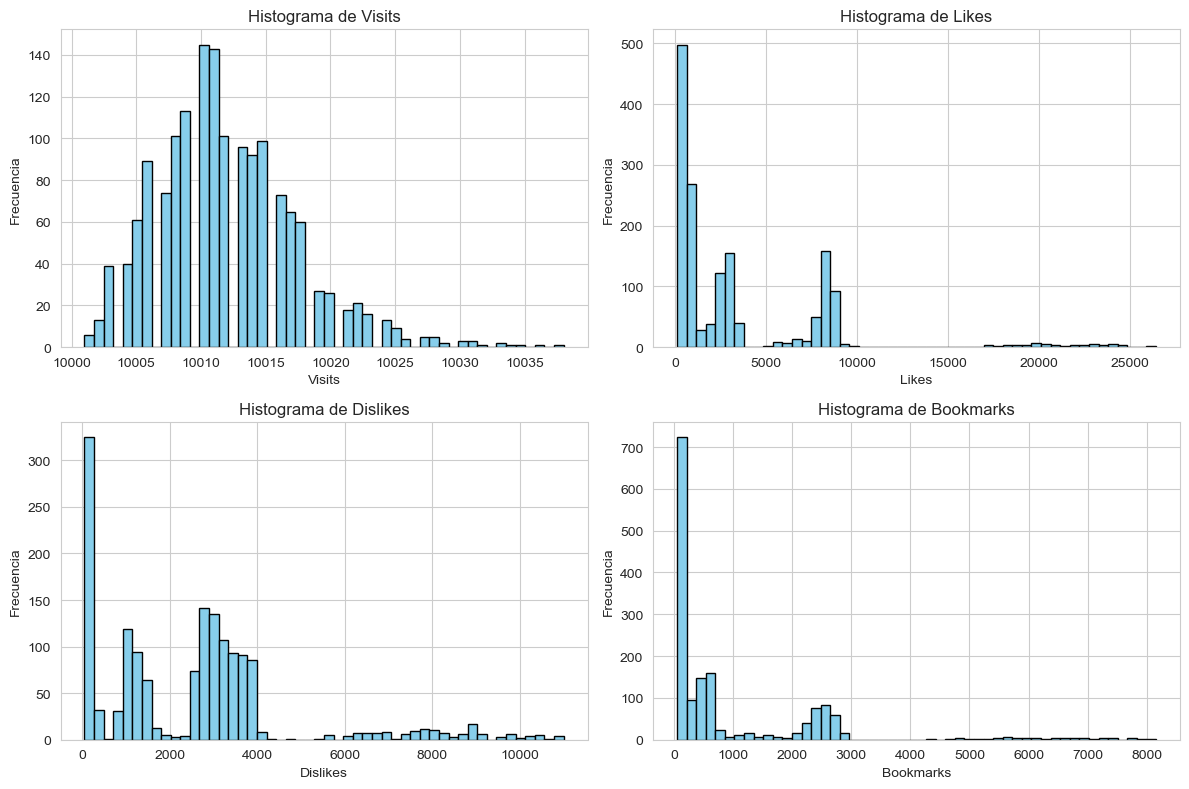

In [31]:
# Exploración de métricas de engagement
cols = ['Visits', 'Likes', 'Dislikes', 'Bookmarks']

# Crear figura con 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # Para iterar fácilmente

for i, col in enumerate(cols):
    axes[i].hist(data[col], bins=50, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


      count         mean          std    min     25%     50%     75%      max
tier                                                                         
1     837.0  4365.144564  5115.466585  104.0  699.00  2648.0  8078.0  26084.0
2     622.0  2812.903537  4230.347543  100.0  360.75   777.0  3033.0  25873.0
3     103.0  2416.951456  4357.468784  108.0  342.50   670.0  2800.5  26425.0
4       7.0  4816.285714  8572.102615  113.0  314.50   576.0  4771.0  22854.0


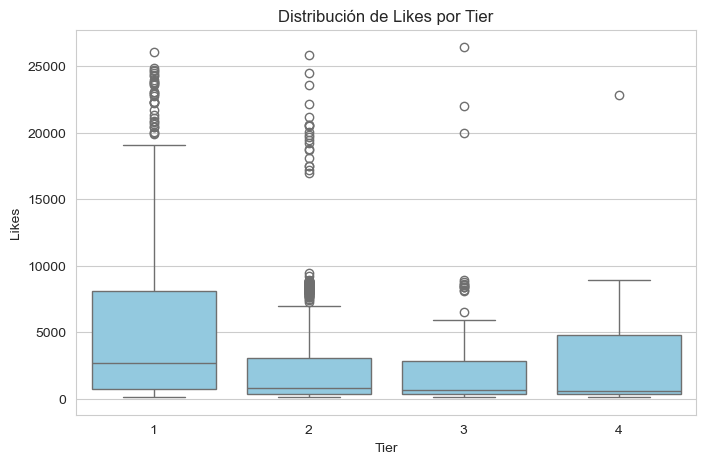

In [32]:
# Estadísticas de Likes por Tier
tier_stats = data.groupby('tier')['Likes'].describe()
print(tier_stats)

# Boxplot de Likes por Tier
plt.figure(figsize=(8,5))
sns.boxplot(x='tier', y='Likes', data=data, color='skyblue')
plt.title('Distribución de Likes por Tier')
plt.xlabel('Tier')
plt.ylabel('Likes')
plt.show()


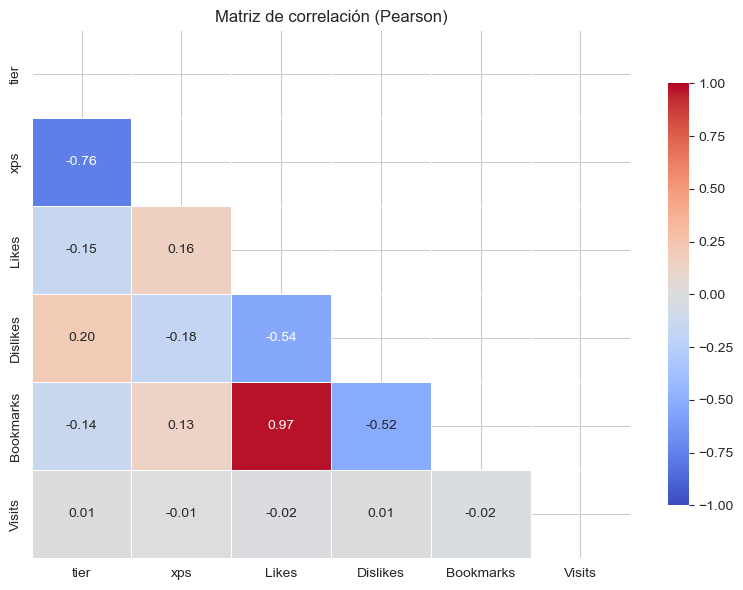

In [33]:
num_cols = ['tier', 'xps', 'Likes', 'Dislikes', 'Bookmarks', 'Visits']
corr = data[num_cols].corr(method='pearson')

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, 
            annot=True,          
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            mask=mask,           
            linewidths=.5, 
            fmt=".2f",           
            cbar_kws={"shrink": .8})

plt.title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

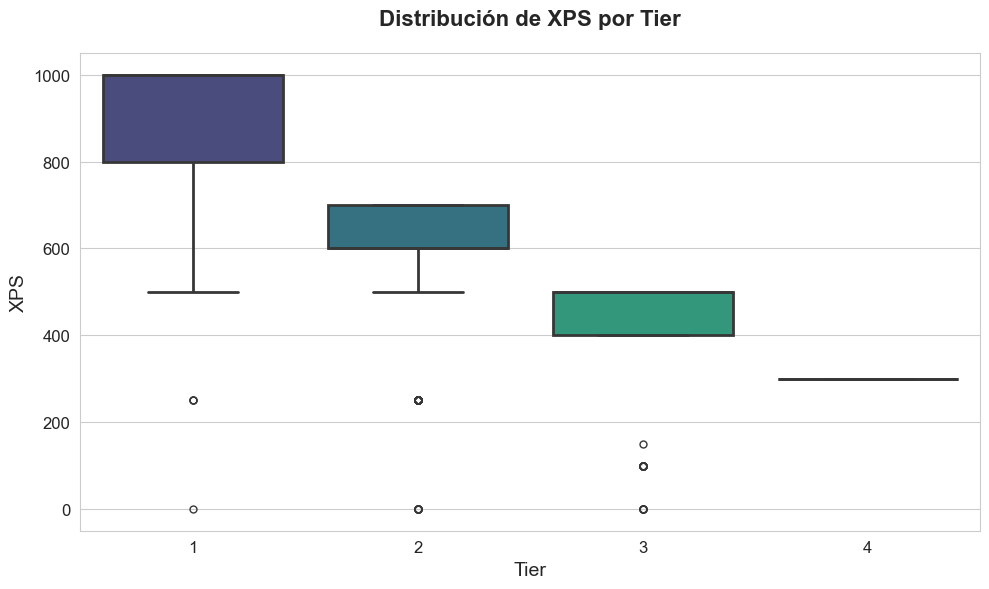

In [34]:
sns.set_style("whitegrid")  
plt.figure(figsize=(10, 6))  

# Boxplot mejorado
ax = sns.boxplot(
    x='tier', 
    y='xps', 
    data=data,
    palette="viridis",          
    linewidth=2,                
    fliersize=5,                
    order=sorted(data['tier'].unique())  
)

plt.title("Distribución de XPS por Tier", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Tier", fontsize=14)
plt.ylabel("XPS", fontsize=14)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

#### Observación:  Existe multicolinealidad entre Likes y Bookmarks con un ρ valor = 0.97, se podría eliminar una de las dos o combinarlas en un `engagement_score = Likes + Bookmarks`.  Polaridad entre las opiniones, variables como Likes y Dislikes correlacionan -0.54, indicando que representan extremos opuestos de la misma métrica, algo esperado en el mundo real. Relación inversa Tier vs XPs con un ρ valor = -0.76 sugiere que los POIs más relevantes (Tier alto) requieren menor “experiencia” (XPs) del usuario, o que se calculan con criterios distintos.  La variable Visits es casi independiente del resto de variables lo que podría aportar señal adicional. Pasos sugeridos: 
  
- #### Revisar multicolinealidad antes de entrenar modelos lineales.  
- #### Considerar fusión o eliminación de Likes & Bookmarks.  
- #### Analizar más a fondo la definición de Tier y XPs para comprender su relación.


### Detección de duplicados sobre columna tipo object  
Se verifica si el identificador `id`, que debería ser único para cada POI, se repite en el dataset.

In [35]:
# Número de filas duplicadas 
dup_rows = data['id'].duplicated().sum()

# Porcentaje de filas duplicadas
pct_rows = dup_rows / len(data) * 100

print(f"Filas duplicadas: {dup_rows} ({pct_rows:.1f} %)")

# IDs que aparecen más de una vez
duplicate_ids = data.loc[data['id'].duplicated(keep=False), 'id'].unique()

print(f"Número de POIs con IDs duplicados: {len(duplicate_ids)}")

# Mostrar las filas duplicadas por cada ID
for poi_id in duplicate_ids:
    duplicate_rows = data[data['id'] == poi_id]
    print(f"\nFilas duplicadas para ID {poi_id}:")
    print(duplicate_rows)

Filas duplicadas: 77 (4.9 %)
Número de POIs con IDs duplicados: 23

Filas duplicadas para ID 04be145b-f73e-41aa-9332-d1702684dc53:
                                        id                   name  \
1178  04be145b-f73e-41aa-9332-d1702684dc53  El bosque de Dartmoor   
1179  04be145b-f73e-41aa-9332-d1702684dc53  El bosque de Dartmoor   
1180  04be145b-f73e-41aa-9332-d1702684dc53  El bosque de Dartmoor   
1181  04be145b-f73e-41aa-9332-d1702684dc53  El bosque de Dartmoor   

                                       shortDescription  \
1178  Explora Dartmoor, el misterioso páramo que ins...   
1179  Explora Dartmoor, el misterioso páramo que ins...   
1180  Explora Dartmoor, el misterioso páramo que ins...   
1181  Explora Dartmoor, el misterioso páramo que ins...   

                                       categories  tier  locationLon  \
1178  ['Ocio', 'Historia', 'Cultura', 'Misterio']     1    -3.901605   
1179  ['Ocio', 'Historia', 'Cultura', 'Misterio']     1    -3.901605   
1180  ['Oci

In [36]:
non_numeric_cols = data.select_dtypes(exclude='number').columns.tolist()
print(non_numeric_cols)

for col in non_numeric_cols:
    print(f"{col} → {type(data[col][0])}")

['id', 'name', 'shortDescription', 'categories', 'tags', 'main_image_path']
id → <class 'str'>
name → <class 'str'>
shortDescription → <class 'str'>
categories → <class 'str'>
tags → <class 'str'>
main_image_path → <class 'str'>


#### Observación: La variable categories / tags son string que representan listas, se convertiran a listas en la fase de preprocesado y probablemente se usara un embedding para transformarlas, por otro lado, la variable shortDescription es un texto libre, se usara tokenizacion para tratarlas más adelante, la variable main_image_path nos da la ruta local de la imagen solo te tendría que asegurar que todas existan y sean accesibles, finalmente para la variable id hay que asegurarse de resolver los duplicados.

### Análisis espacial (lon / lat)
Revisión de los datos espaciales de los POI al rededor del mundo

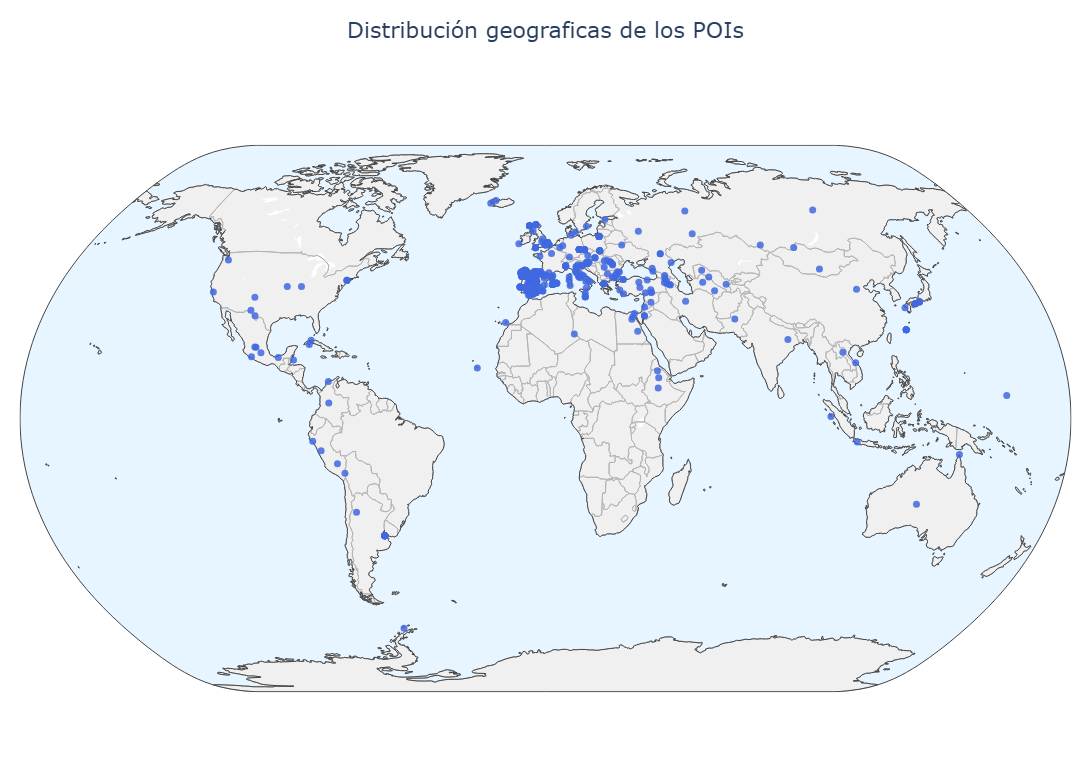

In [39]:
fig = px.scatter_geo(
    data,
    lat="locationLat",
    lon="locationLon",
    hover_name="name",
    hover_data={"tier": True, "Likes": True},
    projection="natural earth",
    width=1100,   # Optimizado para PDF
    height=750
)

fig.update_traces(
    marker=dict(
        size=7,
        opacity=0.85,
        color="royalblue"
    )
)

fig.update_layout(
    title=dict(
        text="Distribución geograficas de los POIs",
        font=dict(size=22),
        x=0.5,              # Centrado horizontal real
        xanchor="center",   # Ancla al centro
        y=0.97              # Mejor posición vertical
    ),
    geo=dict(
        showland=True,
        landcolor="rgb(240,240,240)",
        showcountries=True,
        countrycolor="rgb(180,180,180)",
        showocean=True,
        oceancolor="rgb(230,245,255)"
    ),
    margin=dict(l=20, r=20, t=90, b=20),  # Más espacio superior para título
    font=dict(size=14)
)

fig.show()


### Visualización de Imagenes y estadisticas
Se uso un modelo de mejora de resolución, precisamente el modelo EDSR (Enhanced Deep Super-Resolution) solo con fines exploratorio y de análisis para ver patrones entender las imagenes

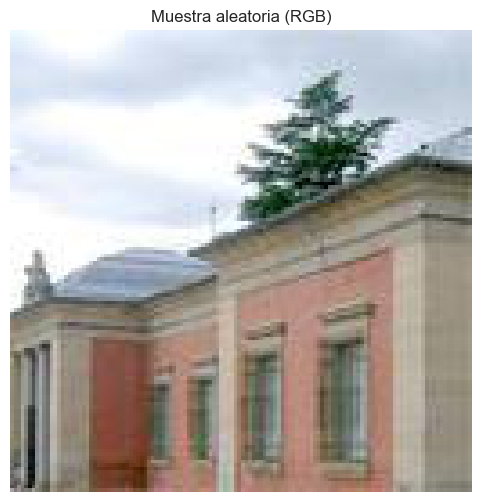

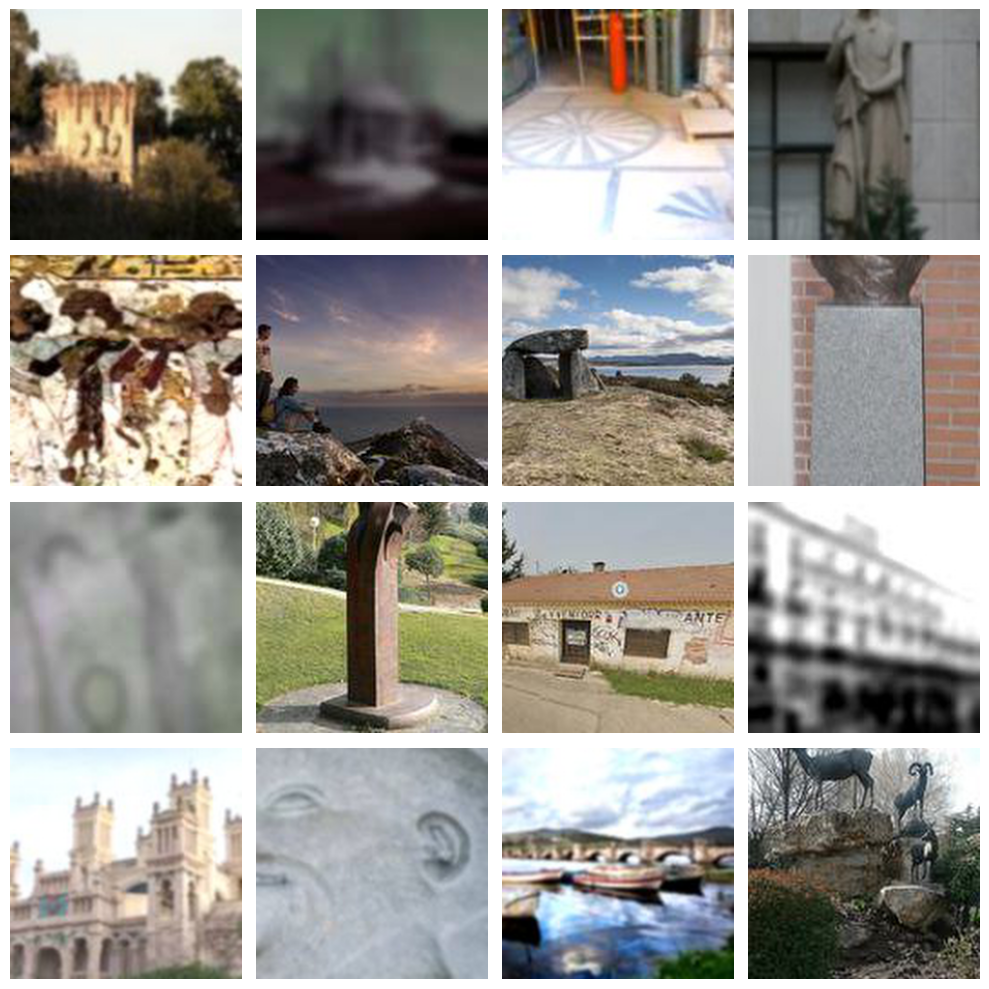

Mean (R,G,B): [0.433491 0.448859 0.454272]
Std  (R,G,B): [0.274293 0.264425 0.268527]


In [40]:
# 1. Mostrar una imagen correctamente 
idx = random.randint(0, len(data)-1)
img = cv2.imread(data['main_image_path'].iloc[idx])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Muestra aleatoria (RGB)')
plt.show()

# 2. Grid 4×4 más bonito y rápido (preload + mismo tamaño)
fig, axes = plt.subplots(4, 4, figsize=(10,10))
axes = axes.ravel()

selected_paths = data['main_image_path'].sample(16, random_state=42).values

for i, path in enumerate(selected_paths):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Opcional: resize suave para que todas tengan mismo tamaño (mejora visual)
    img_rgb = cv2.resize(img_rgb, (224, 224), interpolation=cv2.INTER_LANCZOS4)
    
    axes[i].imshow(img_rgb)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 3. Estadísticas más robustas y útiles
stats = []
sample_paths = data['main_image_path'].sample(200, random_state=42).values

for p in sample_paths:
    img = cv2.imread(p)
    img_norm = img.astype(np.float32) / 255.0
    stats.append(img_norm.reshape(-1, 3))

stats = np.concatenate(stats, axis=0)

print("Mean (R,G,B):", np.round(stats.mean(axis=0), 6))
print("Std  (R,G,B):", np.round(stats.std(axis=0), 6))

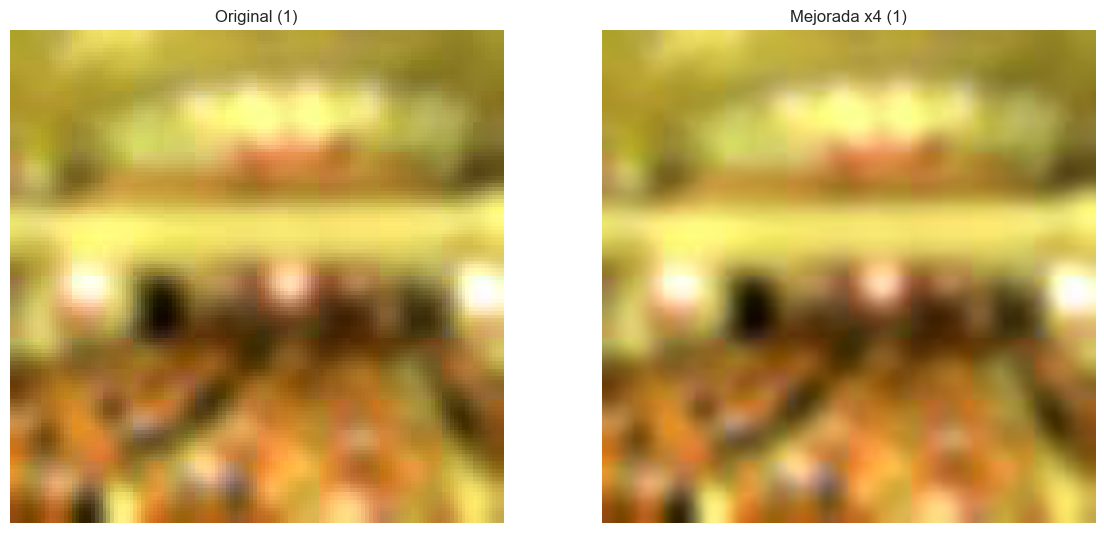

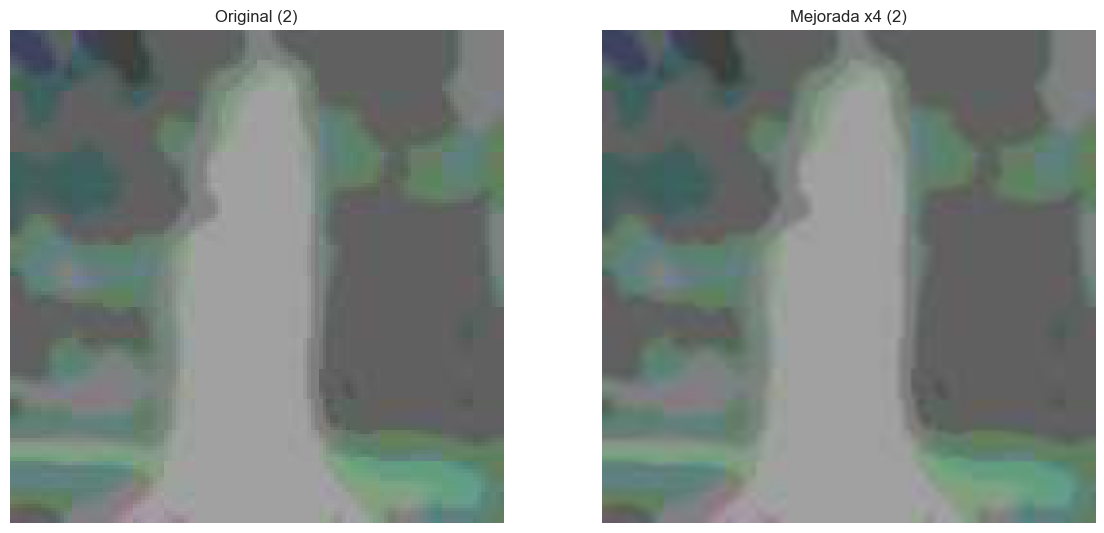

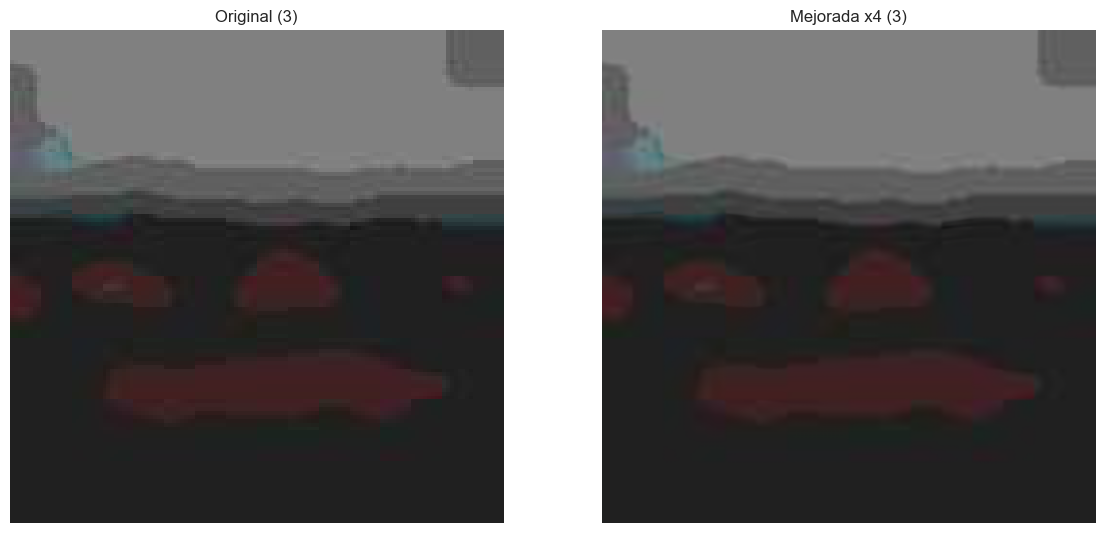

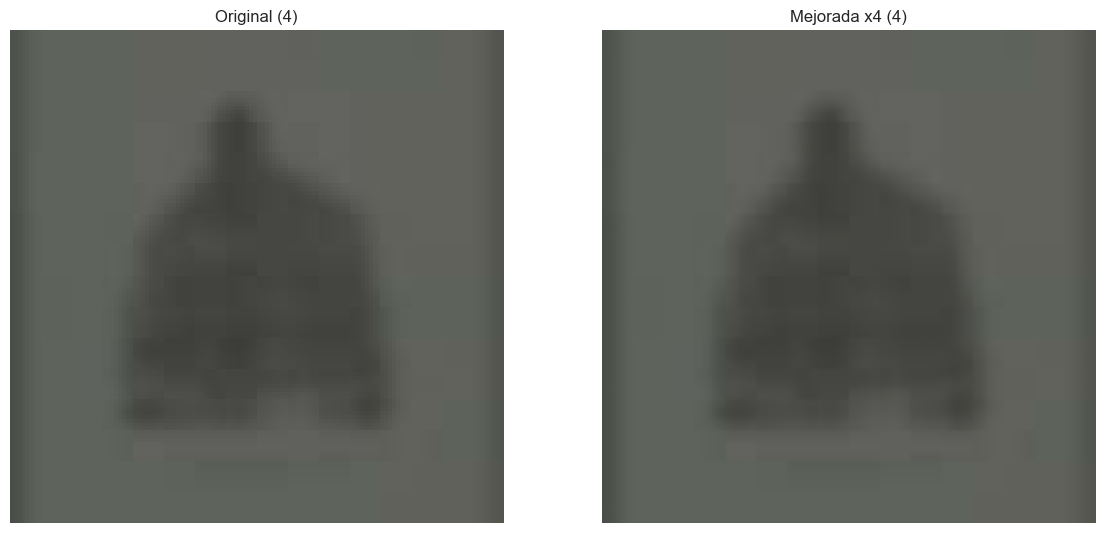

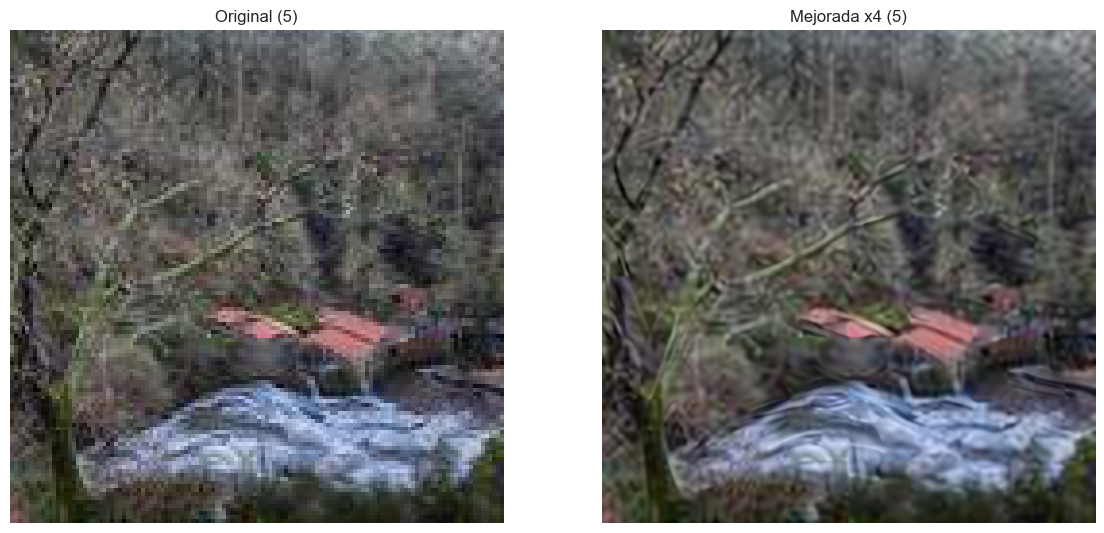

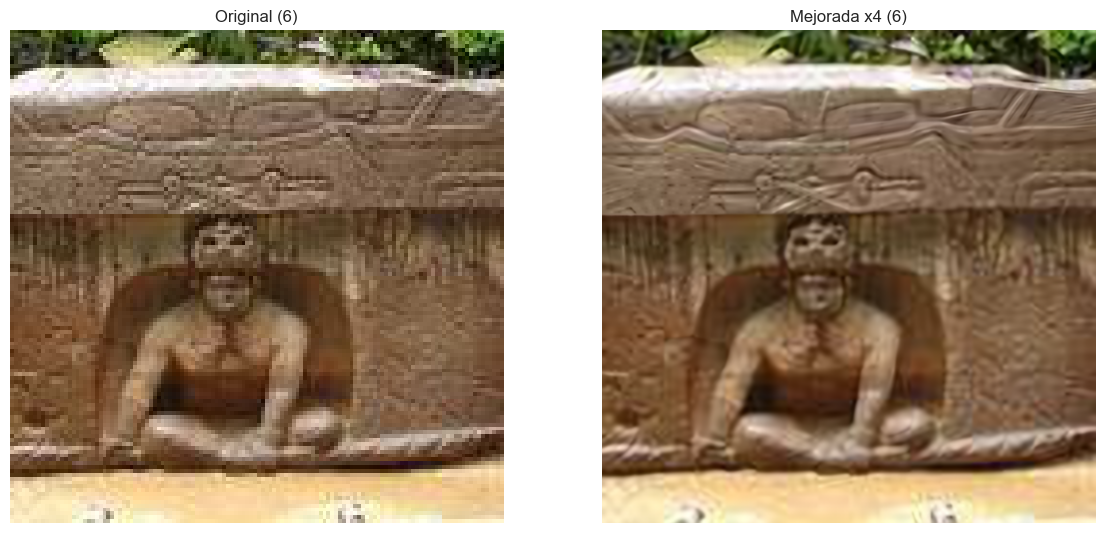

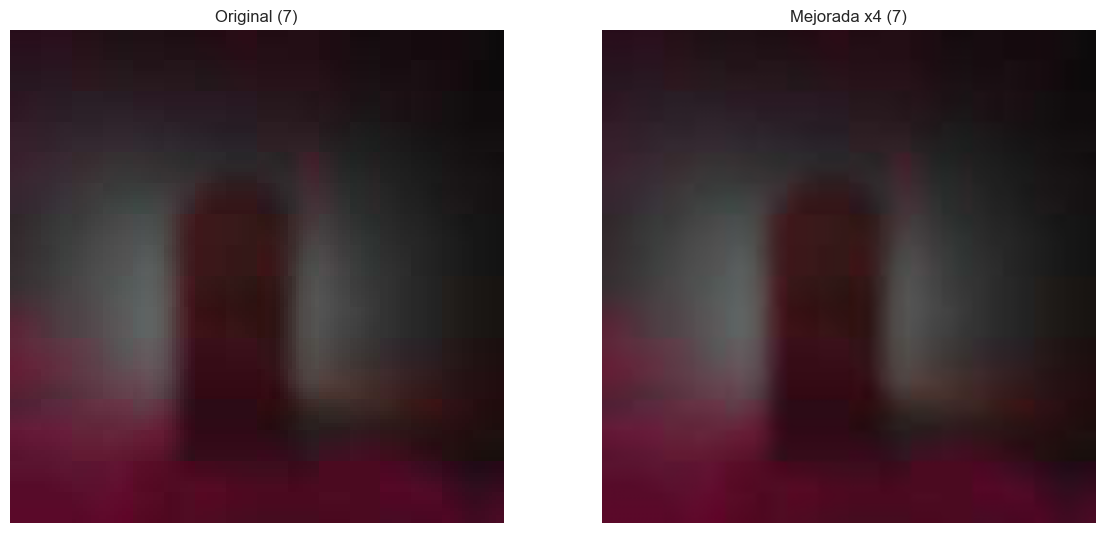

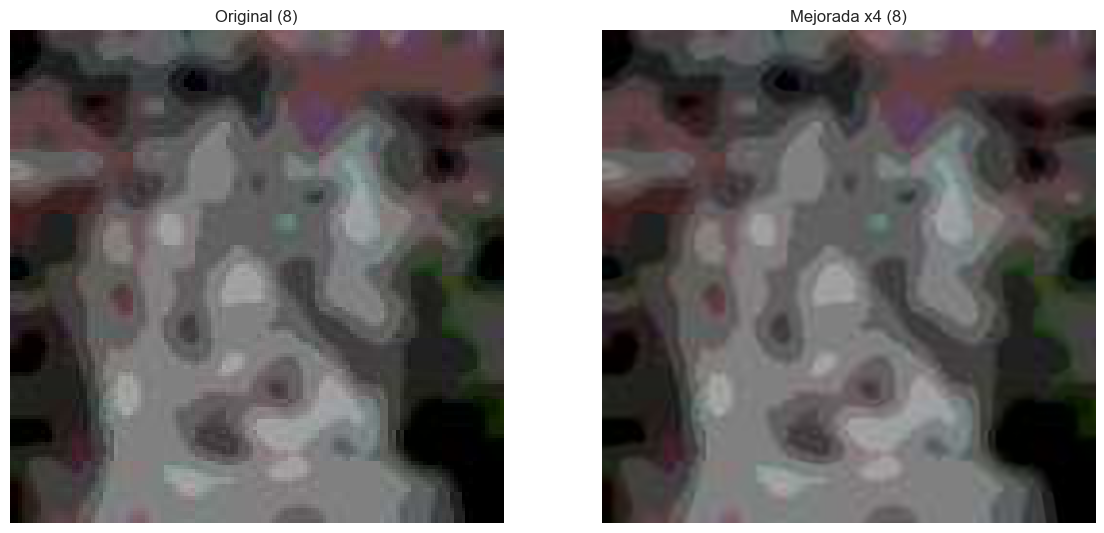

In [42]:
# Mejora de resolución con modelo EDSR (Enhanced Deep Super-Resolution) con imagenes al azar

# Configurar super-resolución con OpenCV 
sr = cv2.dnn_superres.DnnSuperResImpl_create()
sr.readModel("EDSR_x4.pb")  # Ruta al modelo descargado
sr.setModel("edsr", 4)      # Modelo EDSR, escala x4

# Seleccionar entre 5 y 10 imágenes aleatorias
num_imgs = random.randint(5, 10)
paths = random.sample(list(data['main_image_path']), num_imgs)

for i, path in enumerate(paths, 1):
    img_original = cv2.imread(path)
    if img_original is None:
        print(f"Error cargando imagen: {path}")
        continue

    img_mejorada = sr.upsample(img_original)

    # Mostrar antes y después
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Original ({i})")
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(img_mejorada, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Mejorada x4 ({i})")
    axes[1].axis('off')

    plt.show()

#### Observación: En la siguiente tabla se puede ver que la media ronda los 0.44 en un rango de 0-1 con ligera predominancia al azul, así como, una disperción homogénea entre los canales indicando buen balance de color, esto indica que habra que normalizar imágenes usando "(x – mean) / std" con valores anteriores, aplicar data augmentation como flip, rotate, color-jitter para compensar el blur y aumentar la variabilidad visual y considerar reescalar a 224 × 224 px para fine-tunear redes preentrenadas (ResNet, EfficientNet, etc.).

#### Estadística global de píxeles

| Canal | Media | Desv. estándar |
|-------|-------|----------------|
| R     | 0.433 | 0.274          |
| G     | 0.449 | 0.264          |
| B     | 0.454 | 0.268          |

---

# Parte 2 - Definición de target de engagement

### Análisis del target de engagement

Se explorará la mejor manera de definir la variable objetivo (target) que refleje el interés de los usuarios por cada POI.  

Se analizarán las métricas disponibles (Visits, Likes, Bookmarks, Dislikes) para decidir:  

- Si combinarlas en un único `engagement_score`.  
- Qué transformaciones aplicar para reducir el sesgo (por ejemplo, `log1p`).  
- Si abordar el problema como regresión o clasificación (alto/bajo engagement).

In [43]:
# Vamos a visualizar los campos de Visits, Likes, Bookmarks, Dislikes
visits = data['Visits'].fillna(0)
print("Visits statistics:")
print(visits.describe())
print("\n")

print("Likes statistics:")
print(data['Likes'].describe()) 
print("\n")

print("Bookmarks statistics:")
print(data['Bookmarks'].describe())
print("\n")

print("Dislikes statistics:")
print(data['Dislikes'].describe())

Visits statistics:
count     1569.000000
mean     10011.943276
std          5.456808
min      10001.000000
25%      10008.000000
50%      10011.000000
75%      10015.000000
max      10038.000000
Name: Visits, dtype: float64


Likes statistics:
count     1569.000000
mean      3623.908222
std       4817.879374
min        100.000000
25%        464.000000
50%       1434.000000
75%       6840.000000
max      26425.000000
Name: Likes, dtype: float64


Bookmarks statistics:
count    1569.000000
mean      973.261950
std      1453.333948
min        50.000000
25%       116.000000
50%       306.000000
75%      1309.000000
max      8157.000000
Name: Bookmarks, dtype: float64


Dislikes statistics:
count     1569.000000
mean      2526.305927
std       2225.543360
min         52.000000
25%        937.000000
50%       2718.000000
75%       3399.000000
max      10999.000000
Name: Dislikes, dtype: float64


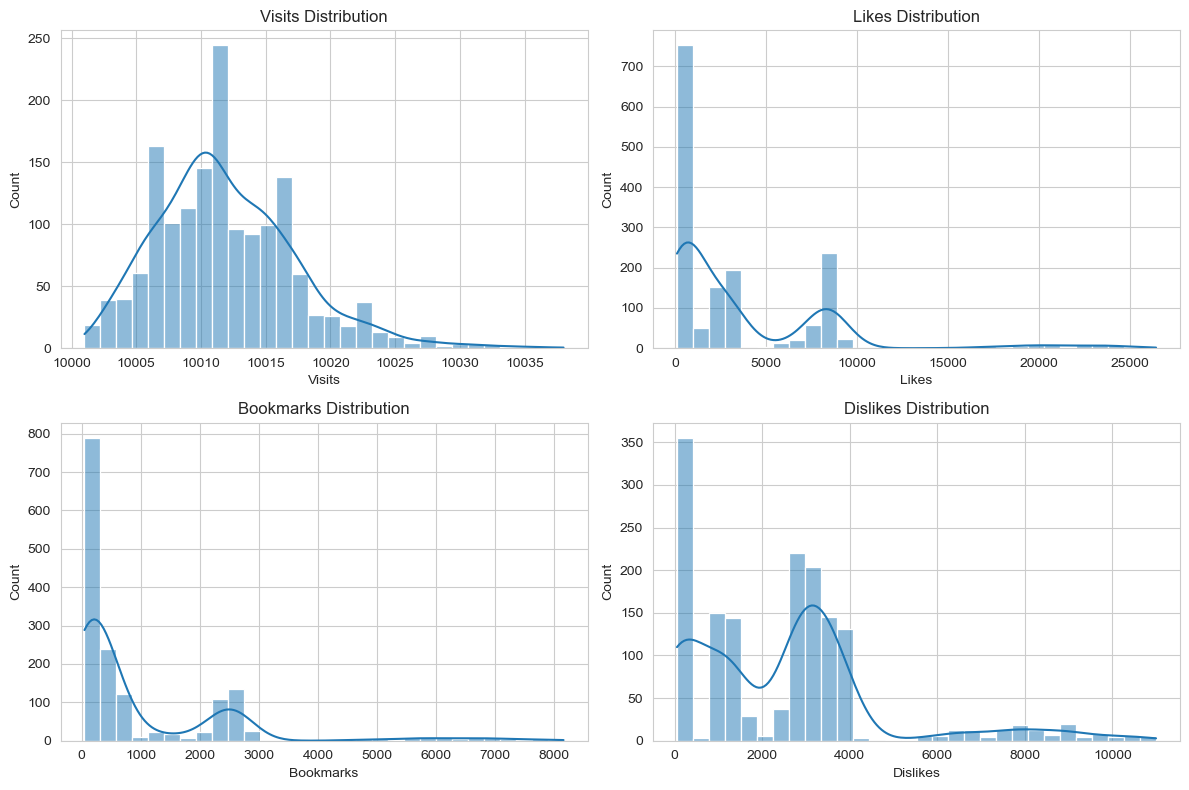

In [45]:
# Generamos histogramas para cada uno de los campos

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.histplot(visits, bins=30, kde=True)
plt.title('Visits Distribution')
plt.subplot(2, 2, 2)
sns.histplot(data['Likes'], bins=30, kde=True)
plt.title('Likes Distribution')
plt.subplot(2, 2, 3)
sns.histplot(data['Bookmarks'], bins=30, kde=True)
plt.title('Bookmarks Distribution')
plt.subplot(2, 2, 4)
sns.histplot(data['Dislikes'], bins=30, kde=True)
plt.title('Dislikes Distribution')
plt.tight_layout()
plt.show()

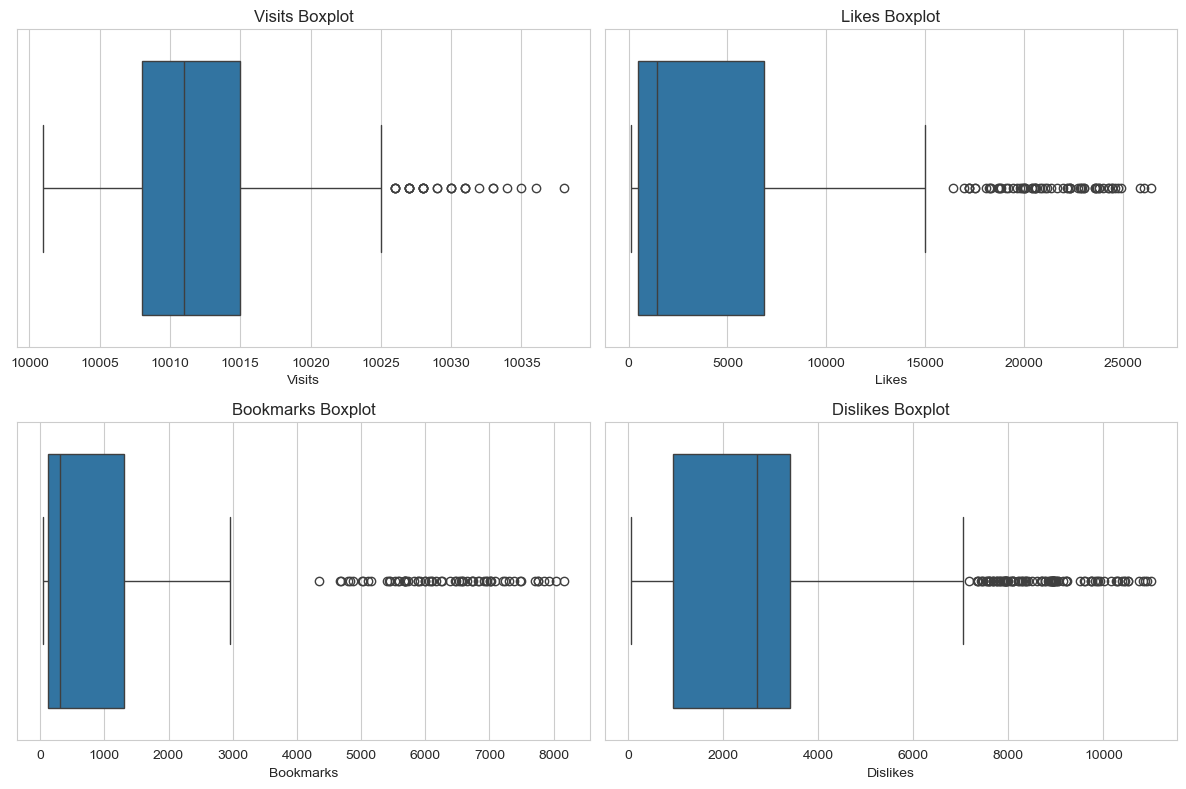

In [46]:
# Vamos a visualzar con unos boxplots los datos de Visits, Likes, Bookmarks, Dislikes
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.boxplot(x=visits)
plt.title('Visits Boxplot')
plt.subplot(2, 2, 2)
sns.boxplot(x=data['Likes'])
plt.title('Likes Boxplot')
plt.subplot(2, 2, 3)
sns.boxplot(x=data['Bookmarks'])
plt.title('Bookmarks Boxplot')
plt.subplot(2, 2, 4)
sns.boxplot(x=data['Dislikes'])
plt.title('Dislikes Boxplot')
plt.tight_layout()
plt.show()

#### Análisis exploratorio de las métricas de *engagement*

El análisis de las métricas revela patrones distintos en cada indicador. **Visits** muestra una distribución altamente concentrada, con la mayoría de los POIs registrando valores muy similares, lo que sugiere que aporta poca variabilidad y podría tener limitada capacidad predictiva. Por su parte, **Likes** presenta una distribución con cola larga y sesgo positivo pronunciado, con valores que oscilan desde aproximadamente 100 hasta más de 26,000, por lo que es recomendable aplicar una transformación `log1p`. **Bookmarks** se comporta de manera similar a *Likes*, aunque en menor escala, mostrando fuerte asimetría y varios valores atípicos. **Dislikes** también exhibe un sesgo marcado, con valores entre ~52 y 11,000, y puede ser útil para capturar polarización cuando se combina con *Likes*.

| Métrica    | Interpretación |
|------------|----------------|
| **Visits** | Distribución extremadamente concentrada: la mayoría de los POIs presentan un número de visitas muy similar. Aporta muy poca variabilidad, por lo que su capacidad predictiva podría ser limitada. |
| **Likes** | Distribución con cola larga y marcado sesgo positivo. Elevada dispersión, con valores que van desde ~100 hasta más de 26,000. Recomendable aplicar una transformación `log1p`. |
| **Bookmarks** | Comportamiento análogo al de *Likes*, aunque en una escala menor. Fuerte asimetría y presencia de varios valores atípicos. |
| **Dislikes** | También muestra un sesgo pronunciado; valores que oscilan aproximadamente entre 52 y 11,000. Puede resultar útil para capturar polarización en combinación con *Likes*. |

A partir de histogramas y *boxplots*, se observan algunas tendencias clave. **Visits** presenta una barra prácticamente uniforme y varianza casi nula, lo que sugiere descartarla o tratarla como constante. En contraste, **Likes**, **Bookmarks** y **Dislikes** muestran colas largas y numerosos *outliers*, reflejando alta dispersión. La variabilidad relativa es especialmente elevada en **Likes** (σ > µ) y **Bookmarks**, indicando que la media no representa adecuadamente la tendencia central. Además, en **Likes** y **Dislikes** se identifican varios “modos” o picos, lo que podría indicar distintos niveles o grupos de popularidad.


## Próximas acciones recomendadas

Se recomienda aplicar la transformación `np.log1p()` sobre **Likes**, **Bookmarks** y **Dislikes** para reducir la asimetría y atenuar las colas largas presentes en estas métricas. Esta transformación ayuda a aproximar las distribuciones a un comportamiento más cercano a la normalidad, facilitando su combinación y análisis posterior. Se sugiere excluir **Visits** del cálculo debido a su rango extremadamente reducido y su limitada capacidad discriminativa, lo que lo hace poco útil para diferenciar el nivel de engagement entre los POIs.

Para definir un **engagement score** inicial se propone combinar las señales positivas (**Likes** y **Bookmarks**) y negativas (**Dislikes**) mediante una fórmula logarítmica:  

$$
\text{engagement\_score} =
\underbrace{\log\Bigl(1 + \beta \cdot \text{Likes} + \gamma \cdot \text{Bookmarks}\Bigr)}_{\text{feedback positivo}}
-
\underbrace{\log\Bigl(1 + \delta \cdot \text{Dislikes}\Bigr)}_{\text{feedback negativo}}
$$

Los **pesos heurísticos** $\beta$, $\gamma$ y $\delta$ se seleccionan con base en el impacto relativo esperado de cada métrica: **Likes** y **Bookmarks** tienen mayor peso porque reflejan aprobación directa y bookmarking del contenido, mientras que **Dislikes** tiene un peso menor para penalizar únicamente el feedback negativo. Esta asignación inicial permite balancear la contribución de cada señal antes de aplicar ajustes más sofisticados basados en análisis de correlación o aprendizaje automático:  

$$
\beta = 0.3, \quad \gamma = 0.4, \quad \delta = 0.1
$$


count    1569.000000
mean        1.531106
std         2.634541
min        -2.009389
25%        -0.733505
50%         0.144818
75%         2.486588
max         6.509728
Name: engagement_score, dtype: float64


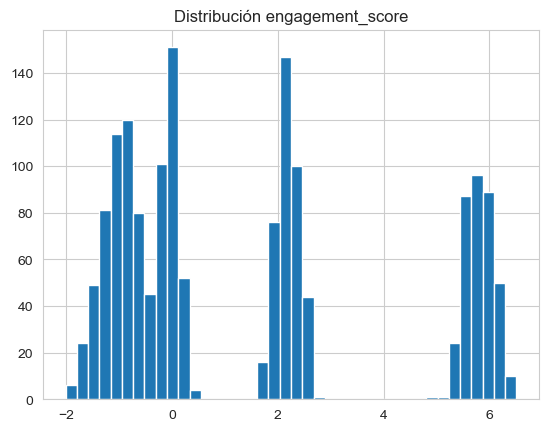

In [47]:
# Definir pesos heurísticos
beta = 0.3   # Likes
gamma = 0.4  # Bookmarks
delta = 0.1  # Dislikes

# Crear engagement_score según nuestra fórmula ponderada
eng_pos = np.log1p(beta * data['Likes'] + gamma * data['Bookmarks'])
eng_neg = np.log1p(delta * data['Dislikes'])
data['engagement_score'] = eng_pos - eng_neg

# Inspección rápida
print(data['engagement_score'].describe())

# Histograma
data['engagement_score'].hist(bins=40)
plt.title("Distribución engagement_score")
plt.show()

# Eliminar columnas redundantes
cols_to_drop = ['Likes', 'Bookmarks', 'Dislikes', 'Visits']
data.drop(columns=cols_to_drop, inplace=True)

In [48]:
# Etiquetar los resultados

labels = ['Low', 'Mid', 'High']
data['eng_cat'] = pd.qcut(
    data['engagement_score'],
    q=3,
    labels=labels
)


print(data['eng_cat'].value_counts())

eng_cat
Low     523
Mid     523
High    523
Name: count, dtype: int64


## Análisis del `engagement_score`

### Estadísticos descriptivos

| count | mean  | std   | min       | 25 %       | 50 %      | 75 %      | max      |
|-------|-------|-------|-----------|------------|-----------|-----------|----------|
| 1 569 | 1.531 | 2.635 | –2.009    | –0.734     | 0.145     | 2.487     | 6.510    |

La media ligeramente positiva (≈ 1.53) sugiere que, en promedio, los POIs reciben más señales de interacción positiva que negativa, mientras que la amplitud del rango (≈ 8.52 puntos) y la desviación estándar (≈ 2.63) indican que existe suficiente variabilidad para diferenciar distintos niveles de engagement entre los POIs.  

El histograma del `engagement_score` muestra un patrón con **tres niveles diferenciables**: una **zona negativa** entre aproximadamente –2 y 0, una **zona neutra** alrededor de 0 a 2.5, y una **zona alta** por encima de ~2.5, lo que refleja distintos grados de popularidad o interacción de los POIs.  

---

## Categorización del target

Para facilitar el entrenamiento de modelos de clasificación, el score se discretizó en **terciles** mediante `pd.qcut(q=3)`, generando clases balanceadas:  

| Clase (`eng_cat`) | Rango de score           | Tamaño |
|------------------|--------------------------|--------|
| **Low**  | ≤ p33 (≈ 0.145)           | ≈ 1/3 |
| **Mid**  | p33 – p66 (≈ 0.145 ↔ 2.487) | ≈ 1/3 |
| **High** | ≥ p66 (≈ 2.487)           | ≈ 1/3 |

**Ventaja principal**: Esta categorización balanceada permite estabilizar el entrenamiento de modelos de clasificación, asegurando que cada clase tenga representación similar de POIs y facilitando la predicción de distintos niveles de engagement.

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1569 entries, 0 to 1568
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   id                1569 non-null   object  
 1   name              1569 non-null   object  
 2   shortDescription  1569 non-null   object  
 3   categories        1569 non-null   object  
 4   tier              1569 non-null   int64   
 5   locationLon       1569 non-null   float64 
 6   locationLat       1569 non-null   float64 
 7   tags              1569 non-null   object  
 8   xps               1569 non-null   int64   
 9   main_image_path   1569 non-null   object  
 10  engagement_score  1569 non-null   float64 
 11  eng_cat           1569 non-null   category
dtypes: category(1), float64(3), int64(2), object(6)
memory usage: 136.6+ KB


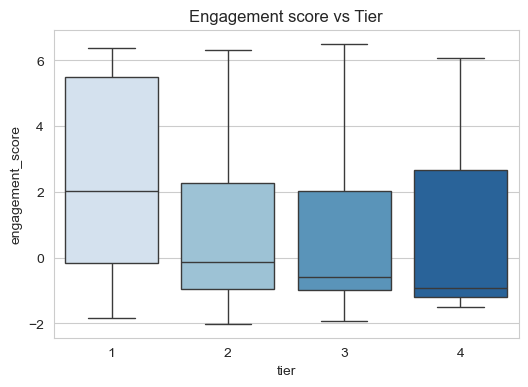

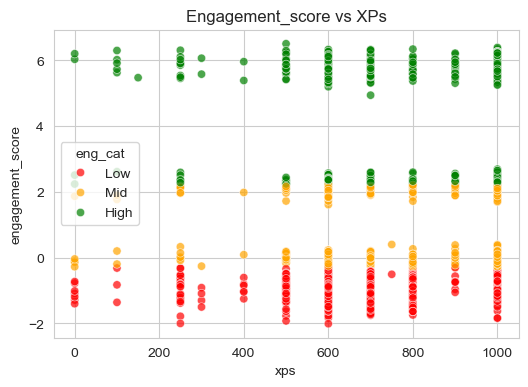

In [53]:
# --- 1. tier vs engagement_score -------------------------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x='tier', y='engagement_score', data=data, palette='Blues')
plt.title('Engagement score vs Tier'); plt.show()

# --- 2. xps vs engagement_score --------------------------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x='xps', y='engagement_score', hue='eng_cat',
                data=data, palette={'Low':'red','Mid':'orange','High':'green'},
                alpha=0.7)
plt.title('Engagement_score vs XPs'); plt.show()

## Análisis de ambas variables vs engagement_score

**1. Boxplot: Engagement score vs Tier**  
Se observa una **tendencia claramente contraria a la intuición esperada**: el **tier 1** (el de menor “relevancia oficial”) muestra la **mediana de engagement más alta** de todos los tiers, además de una **dispersión muy grande** (muchos valores altos y outliers positivos). A partir del tier 2 ya la mediana cae a valores negativos o cercanos a cero, y en tiers 3–4 predomina claramente el **engagement negativo** con menor variabilidad hacia arriba.   

**Conclusión**: El tier oficial no es un buen indicador predictivo de engagement real; de hecho, parece comportarse de forma inversa en promedio.

**2. Scatter plot: Engagement_score vs XPs**  
Se aprecia que:  
- Los puntos **High** (verdes) se concentran casi exclusivamente en valores positivos altos de engagement (~4 a 6), y aparecen de manera bastante uniforme a lo largo de todo el rango de xps (0–1000).  
- Los puntos **Low** (rojos) dominan fuertemente los valores negativos, especialmente en la zona baja-media de xps, aunque también aparecen en todo el rango.  
- Los **Mid** (amarillos) se sitúan en una banda intermedia estrecha (~0 a 2), sin alcanzar valores muy altos ni muy bajos.

**Conclusión**: El valor de **xps** no muestra una relación clara ni monotónica con el engagement_score (no hay tendencia creciente ni decreciente visible). La separación efectiva entre categorías de engagement (Low / Mid / High) ocurre casi exclusivamente en el eje vertical (engagement_score), mientras que el eje horizontal (xps) aporta muy poca información discriminante.

**Resumen general**  
Ninguno de los dos gráficos apoya la idea de que tier o xps sean proxies fuertes o directos del engagement real de los usuarios en este dataset.


---

# Parte 3 - Preprocesado de datos

#### Objetivo del preprocesado mediante las siguientes tareas:

- Resolución de duplicados e inconsistencias identificadas durante el análisis exploratorio.
- Conversión y limpieza de columnas de tipo `object` (por ejemplo, *categories*, *tags*, etc.).
- Preparación de las métricas de engagement previamente definidas (`eng_cat`, `engagement_score`).
- Almacenamiento del conjunto de datos final en el archivo `poi_dataset_prepared.csv`.


## Conversión de columnas `object`

- Transformación de **categories** y **tags** a estructuras de tipo **lista en Python**.

In [54]:
# Transformamos las columnas de categoria y tag a listas
data['categories'] = data['categories'].apply(eval)
data['tags'] = data['tags'].apply(eval)

## Fusión de duplicados (IDs repetidos) 

- Agrupar los registros por **id**.
- Combinar los valores de **tags** mediante una unión tipo *set* para eliminar duplicados.
- Mantener la primera fila como referencia para los campos estáticos.

In [56]:
# Vamos a fusionar las columnas id que estan duplicadas
data = data.groupby('id',as_index=False).agg({
    'name': 'first',
    'shortDescription': 'first',
    'categories': 'first',
    'tier': 'first',
    'locationLon': 'first',
    'locationLat': 'first',
    'tags': lambda x: list(set().union(*x)),
    'xps': 'first',
    'main_image_path': 'first',
    'engagement_score': 'mean'
})

In [57]:
# Recalcular etiqueta Low / Mid / High 
labels = ['Low', 'Mid', 'High']

data['eng_cat'] = pd.qcut(
    data['engagement_score'],
    q=3,
    labels=labels
).astype('category')              

print(data['eng_cat'].value_counts())

eng_cat
High    498
Low     497
Mid     497
Name: count, dtype: int64


In [58]:
print(data.shape)

(1492, 12)


## Ingeniería de listas 

- **Categories**: conversión a índices numéricos y posterior generación de *embeddings*.
- **Tags**: cálculo del número total de etiquetas por POI y transformación de este conteo a una variable numérica.

In [59]:
# Analizamos la distribución de las categorias
categories = data['categories'].value_counts()
categories

categories
[Patrimonio, Historia, Arquitectura]           100
[Patrimonio, Arquitectura, Historia]            84
[Historia, Cultura, Escultura]                  76
[Cultura, Escultura, Historia]                  66
[Cultura, Arquitectura, Historia]               64
                                              ... 
[Ocio, Ciencia, Arquitectura]                    1
[Ocio, Escultura, Naturaleza]                    1
[Historia, Escultura, Ciencia]                   1
[Historia, Cultura, Arquitectura, Misterio]      1
[Ocio, Cultura, Historia]                        1
Name: count, Length: 224, dtype: int64

## Elección de *embedding* de índices para la columna `categories`

La columna **categories** contiene listas de hasta 12 etiquetas por POI, como `['Historia', 'Cultura']`, y para que el modelo pueda procesarlas es necesario convertirlas en representaciones numéricas. Utilizar *embeddings* de índices permite representar cada categoría mediante un vector denso de dimensiones controladas (por ejemplo, 8 dimensiones), evitando el uso de múltiples variables binarias dispersas como en la codificación *one-hot*. Además, esta técnica permite capturar relaciones semánticas entre categorías —por ejemplo, *Historia* y *Patrimonio* pueden tener vectores cercanos en el espacio de embedding—, lo que no sería posible con codificación tradicional. En la fase de preprocesado, se asigna un índice entero a cada categoría (del 1 al *N*, reservando 0 para `<pad>`), y cada POI se transforma en una secuencia de índices como `[5, 9]` o `[1, 2]`, lista que luego se convierte en su correspondiente vector de embedding para ser procesada por el modelo.

In [60]:
all_cats = sorted({c for cats in data['categories'] for c in cats})
stoi     = {cat: idx + 1 for idx, cat in enumerate(all_cats)}   


data['cat_idxs'] = data['categories'].apply(
    lambda cats: [stoi[c] for c in cats]
)

# --- Comprobación rápida ---
print(data[['categories', 'cat_idxs']].head(5))

                                  categories       cat_idxs
0  [Patrimonio, Cultura, Historia, Misterio]  [11, 4, 7, 8]
1                 [Arquitectura, Patrimonio]        [1, 11]
2          [Cultura, Arquitectura, Historia]      [4, 1, 7]
3                   [Arquitectura, Historia]         [1, 7]
4        [Historia, Arquitectura, Escultura]      [7, 1, 5]


## Secuencias *padded*

Tras mapear las listas de categorías a índices numéricos, se genera la variable **`cat_padded`** con longitud fija `MAX_LEN`, rellenando con **0** las posiciones sin categoría para garantizar uniformidad en todas las secuencias. Este *padding* asegura la compatibilidad directa con `nn.Embedding`, permitiendo que el modelo procese de manera consistente todas las secuencias de categorías sin problemas de longitud variable.

In [61]:
cat_seqs = data['cat_idxs'].tolist()             

# ——— Padding a longitud fija ———
MAX_LEN = max(len(seq) for seq in cat_seqs)       # p. ej. 3
PAD_IDX = 0                                       # hemos reservado 0 para <pad>

cat_padded = np.zeros((len(cat_seqs), MAX_LEN), dtype='int64')  # (N, MAX_LEN)
for i, seq in enumerate(cat_seqs):
    cat_padded[i, :len(seq)] = seq               

np.save('cat_seqs.npy', cat_padded) 

                                                tags  tags_count
0  [Museos, Instalación, brujas, Inquisición, Edi...           5
1                                          [s.XVIII]           1
2  [Historia, Madrid, Urbanismo, Arquitectura neo...          13
3                                                 []           0
4  [Historia, Arquitectura moderna, Arte, Aeronáu...          13


Text(0, 0.5, 'Frequency')

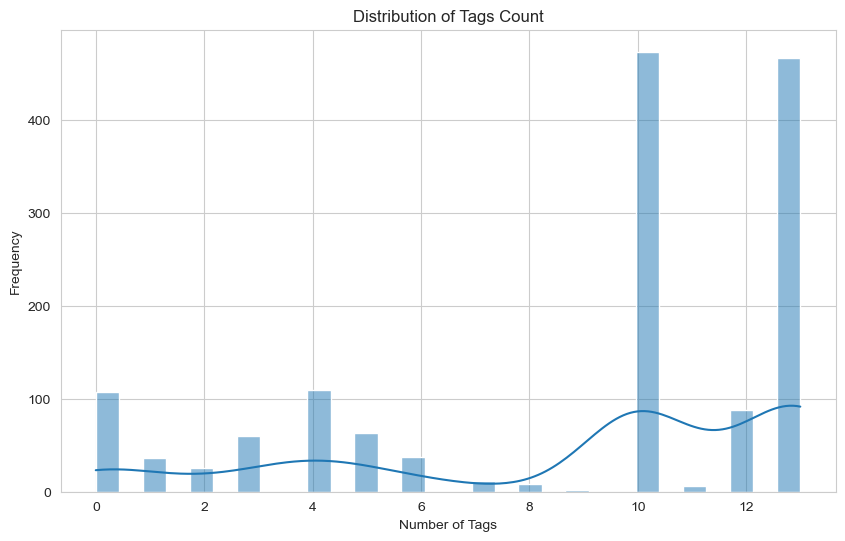

In [62]:
# Transformamos el campo tags lo contamos y añadimos un campo con el numero de tags
data['tags_count'] = data['tags'].apply(len)
# --- Comprobación rápida ---
print(data[['tags', 'tags_count']].head(5))
# --- Visualización de la distribución de tags ---
plt.figure(figsize=(10, 6)) 
sns.histplot(data['tags_count'], bins=30, kde=True)
plt.title('Distribution of Tags Count')
plt.xlabel('Number of Tags')
plt.ylabel('Frequency') 

## Feature de *tags*

- Se incorpora la variable **`tags_count`**, que representa el número total de etiquetas asociadas a cada POI.
- El histograma de esta feature muestra una **distribución multimodal**, con picos claramente definidos en **0** y en el rango de **10–13 tags**, lo que la convierte en una señal informativa para modelos tabulares.

In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   id                1492 non-null   object  
 1   name              1492 non-null   object  
 2   shortDescription  1492 non-null   object  
 3   categories        1492 non-null   object  
 4   tier              1492 non-null   int64   
 5   locationLon       1492 non-null   float64 
 6   locationLat       1492 non-null   float64 
 7   tags              1492 non-null   object  
 8   xps               1492 non-null   int64   
 9   main_image_path   1492 non-null   object  
 10  engagement_score  1492 non-null   float64 
 11  eng_cat           1492 non-null   category
 12  cat_idxs          1492 non-null   object  
 13  tags_count        1492 non-null   int64   
dtypes: category(1), float64(3), int64(3), object(7)
memory usage: 153.2+ KB


## Vectorización de `shortDescription`

Se procesó la columna `shortDescription` verificando primero que las palabras estuvieran en español mediante `DetectorFactory`, evaluando la eliminación o conservación de términos en otros idiomas según su frecuencia. Posteriormente, se descargaron y aplicaron listas de *stop-words* en español desde NLTK, almacenadas en la variable `spanish_sw`, y se realizó una limpieza básica del texto, que incluyó conversión a minúsculas, normalización de acentos y caracteres especiales a ASCII, eliminación de caracteres no alfabéticos y unificación de espacios consecutivos. Sobre este texto limpio se construyó un vector TF-IDF con un vocabulario limitado a 2,000 términos (`max_features=2000`), eliminando las *stop-words*, obteniendo una matriz dispersa de dimensión *(n × 2000)*. Para reducir la dimensionalidad y capturar la semántica latente, se aplicó `TruncatedSVD(n_components=100)`, generando una matriz *(n × 100)* que disminuye el consumo de memoria y ayuda a mitigar el sobreajuste. Finalmente, esta representación reducida se almacenó en el archivo **`desc_vectors.npy`** para su uso posterior en el modelo.

In [64]:
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0

def detect_lang(text: str) -> str:
    try:
        return detect(text)
    except:
        return "unknown"

# Detección de idioma por POI
data["lang"] = (
    data["shortDescription"]
    .fillna("")
    .apply(detect_lang)
)

# Conteo por idioma
lang_counts = data["lang"].value_counts()

# Porcentaje de textos en otro idioma (≠ español)
total_texts = len(data)
non_spanish_texts = total_texts - lang_counts.get("es", 0)
percentage_non_spanish = (non_spanish_texts / total_texts) * 100

print(lang_counts)
print(f"\nPorcentaje de POIs en un idioma distinto del español: {percentage_non_spanish:.2f}%")

lang
es    1485
ca       5
en       2
Name: count, dtype: int64

Porcentaje de POIs en un idioma distinto del español: 0.47%


### Detección de idioma en `shortDescription`

El porcentaje de palabras diferentes al español es casi nulo (≈ 0.47%), lo que indica que la gran mayoría de los POIs tienen descripciones en español. Solo se detectaron unos pocos textos en catalán (5) y en inglés (2). Por esta razón, no será necesario eliminar o filtrar los registros por idioma, y se puede proceder con la vectorización y análisis de texto considerando todo el dataset, manteniendo la integridad de la información disponible.


In [65]:
# Lista de stop-words en español (nltk)
spanish_sw = nltk.corpus.stopwords.words('spanish')


# Función de limpieza mínima

def clean(text: str) -> str:
    text = text.lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii","ignore").decode()
    text = re.sub(r"[^a-z\s]", " ", text)        # solo letras y espacios
    return re.sub(r"\s+", " ", text).strip()

desc_clean = data['shortDescription'].fillna('').map(clean)


# TF-IDF con vocabulario ≤ 2 000 términos

tfidf = TfidfVectorizer(max_features=2000, stop_words=spanish_sw)
X_tfidf = tfidf.fit_transform(desc_clean)          # sparse (n, 2000)


# Reducir a 100 componentes con SVD (LSA)


svd = TruncatedSVD(n_components=100, random_state=42)
X_desc_100 = svd.fit_transform(X_tfidf).astype("float32")  
print("Matriz de descripciones:", X_desc_100.shape)  

# Guardar en disco para usarlo después
np.save("desc_vectors.npy", X_desc_100)  

Matriz de descripciones: (1492, 100)


In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   id                1492 non-null   object  
 1   name              1492 non-null   object  
 2   shortDescription  1492 non-null   object  
 3   categories        1492 non-null   object  
 4   tier              1492 non-null   int64   
 5   locationLon       1492 non-null   float64 
 6   locationLat       1492 non-null   float64 
 7   tags              1492 non-null   object  
 8   xps               1492 non-null   int64   
 9   main_image_path   1492 non-null   object  
 10  engagement_score  1492 non-null   float64 
 11  eng_cat           1492 non-null   category
 12  cat_idxs          1492 non-null   object  
 13  tags_count        1492 non-null   int64   
 14  lang              1492 non-null   object  
dtypes: category(1), float64(3), int64(3), object(8)
memory usage: 164.9+ KB


## Limpieza final de columnas

### Columnas eliminadas como *features*

- **id, name** → Identificadores o metadatos sin relevancia para el modelo.  
- **shortDescription** → Ya vectorizada externamente (TF-IDF + SVD, `desc_vectors.npy`).  
- **engagement_score** → Reemplazada por la versión categórica `eng_cat`.  
- **cat_idx** → Índice crudo de categorías; se conserva la versión *padded* en `cat_seqs.npy`.
- **lang** → Residuo del código anterior

### Columnas que permanecen

- **tier, xps** → Variables numéricas u ordinales.  
- **locationLon, locationLat** → Coordenadas, útiles para generación de features geoespaciales.  
- **tags_count** → Número de etiquetas por POI, refleja densidad semántica.  
- **main_image_path** → Ruta de la imagen, clave para el pipeline multimodal.  
- **eng_cat** → Variable target final (*Low/Mid/High*).


In [67]:
# Eliminación de las columnas
data = data.drop(columns=['id', 'name', 'shortDescription', 'categories', 'tags','shortDescription', 'categories', 'tags','cat_idxs', 'engagement_score', 'lang'])

In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   tier             1492 non-null   int64   
 1   locationLon      1492 non-null   float64 
 2   locationLat      1492 non-null   float64 
 3   xps              1492 non-null   int64   
 4   main_image_path  1492 non-null   object  
 5   eng_cat          1492 non-null   category
 6   tags_count       1492 non-null   int64   
dtypes: category(1), float64(2), int64(3), object(1)
memory usage: 71.6+ KB


In [69]:
data.to_csv('poi_dataset_prepro.csv', index=False)